# MeetSense AI - Meeting Analytics

## Objective

Generate visual analytics from the meeting transcript.

In [3]:
import re
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from wordcloud import WordCloud
import warnings

# Suppress and ignore all warnings globally
warnings.filterwarnings("ignore")

In [5]:
## Load Meeting Transcript
import sys
import os

# Add project root to Python path
project_root = os.path.abspath("..")
sys.path.append(project_root)

from src.utils import read_text

transcript = read_text("../outputs/meeting_transcript.txt")

print(transcript[:500])

 Good morning everyone, thank you for joining today's project planning meeting. Our objective is to finalize the timeline for the AI meeting and diligent system and assigned responsibilities for the first development sprint. Good morning, I have completed the initial research on the speech recognition models. I recommend using open AI whisper because it provides accurate transcription and works well even with the background noise. That sounds good. I will start working on the backend APIs that w


In [6]:
# Clean Transcript
import re

text = transcript.lower()

# Remove punctuation and numbers
text = re.sub(r'[^a-zA-Z\s]', ' ', text)

# Split into words
words = text.split()

print(f"Total Words: {len(words)}")
print(words[:20])

Total Words: 346
['good', 'morning', 'everyone', 'thank', 'you', 'for', 'joining', 'today', 's', 'project', 'planning', 'meeting', 'our', 'objective', 'is', 'to', 'finalize', 'the', 'timeline', 'for']


In [7]:
#Remove Stop Words
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

filtered_words = [
    word
    for word in words
    if word not in ENGLISH_STOP_WORDS and len(word) > 2
]

print(f"Filtered Words: {len(filtered_words)}")
print(filtered_words[:20])

Filtered Words: 191
['good', 'morning', 'thank', 'joining', 'today', 'project', 'planning', 'meeting', 'objective', 'finalize', 'timeline', 'meeting', 'diligent', 'assigned', 'responsibilities', 'development', 'sprint', 'good', 'morning', 'completed']


In [8]:
# Extract Top Keywords

In [9]:
from collections import Counter
import pandas as pd

keyword_counts = Counter(filtered_words)

keyword_df = pd.DataFrame(
    keyword_counts.most_common(10),
    columns=["Keyword", "Frequency"]
)

keyword_df

,Keyword,Frequency
0,meeting,8
1,good,3
2,models,3
3,using,3
4,transcript,3
5,dashboard,3
6,productivity,3
7,morning,2
8,thank,2
9,project,2


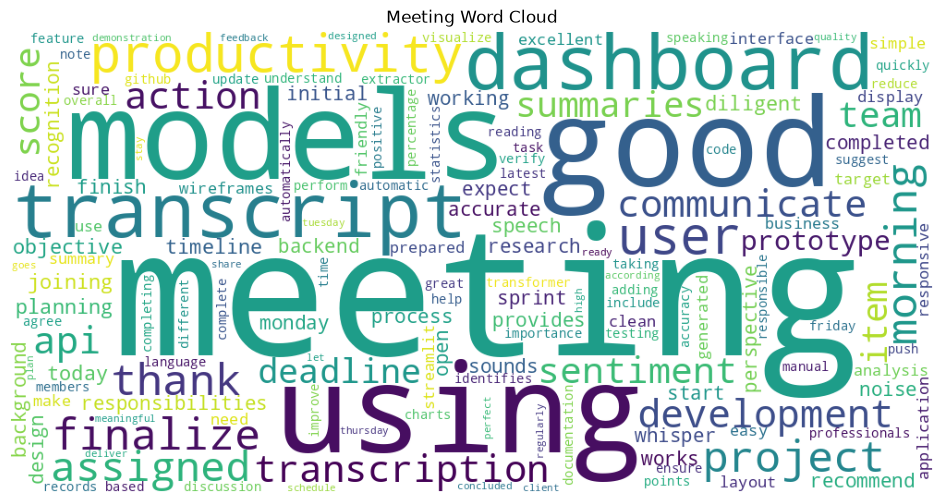

In [10]:
#Generate Word Cloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(" ".join(filtered_words))

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Meeting Word Cloud")
plt.show()

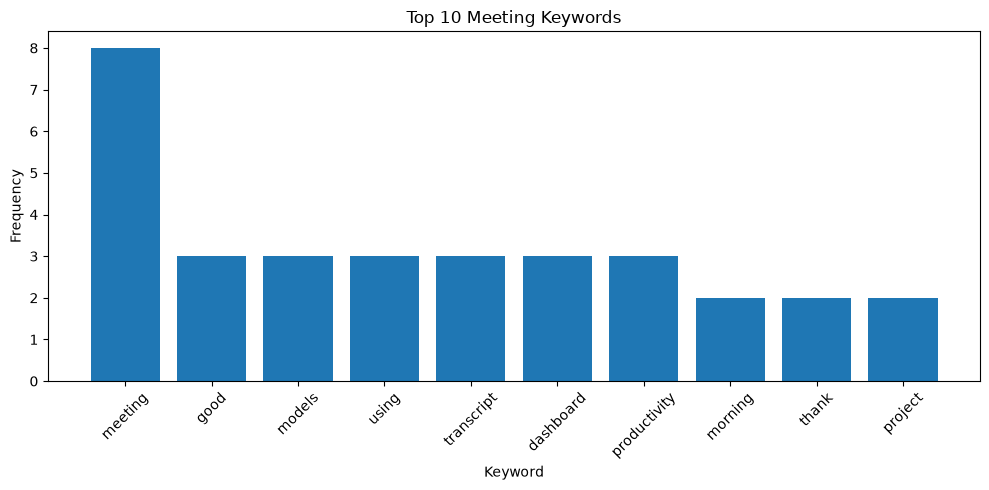

In [11]:
# Plot Top Keywords
plt.figure(figsize=(10,5))

plt.bar(
    keyword_df["Keyword"],
    keyword_df["Frequency"]
)

plt.title("Top 10 Meeting Keywords")
plt.xlabel("Keyword")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [12]:
#Save Analytics
keyword_df.to_csv(
    "../outputs/top_keywords.csv",
    index=False
)

print(" Top keywords saved successfully!")

 Top keywords saved successfully!


In [14]:
## Save Keyword Chart
plt.figure(figsize=(10,5))

plt.bar(
    keyword_df["Keyword"],
    keyword_df["Frequency"]
)

plt.title("Top 10 Meeting Keywords")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../outputs/keyword_chart.png")

plt.close()

print(" Keyword chart saved successfully!")

 Keyword chart saved successfully!


In [15]:
# Notebook Summary

In [18]:
print("=" * 60)
print("MEETSENSE AI - ANALYTICS SUMMARY")
print("=" * 60)

print(f"Total Words        : {len(words)}")
print(f"Filtered Words     : {len(filtered_words)}")
print(f"Top Keywords Found : {len(keyword_df)}")

print("\nTop Keywords:")
print(keyword_df)

print("\n  Completed Successfully!")

MEETSENSE AI - ANALYTICS SUMMARY
Total Words        : 346
Filtered Words     : 191
Top Keywords Found : 10

Top Keywords:
        Keyword  Frequency
0       meeting          8
1          good          3
2        models          3
3         using          3
4    transcript          3
5     dashboard          3
6  productivity          3
7       morning          2
8         thank          2
9       project          2

  Completed Successfully!
